In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('dark_background')
os.makedirs('charts', exist_ok=True)

matches = pd.read_csv('matches_clean.csv')
deliveries = pd.read_csv('deliveries_clean.csv')

print("Data loaded")

Data loaded


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16628\4232082113.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_scorers, x='total_runs', y='batter', palette='viridis')


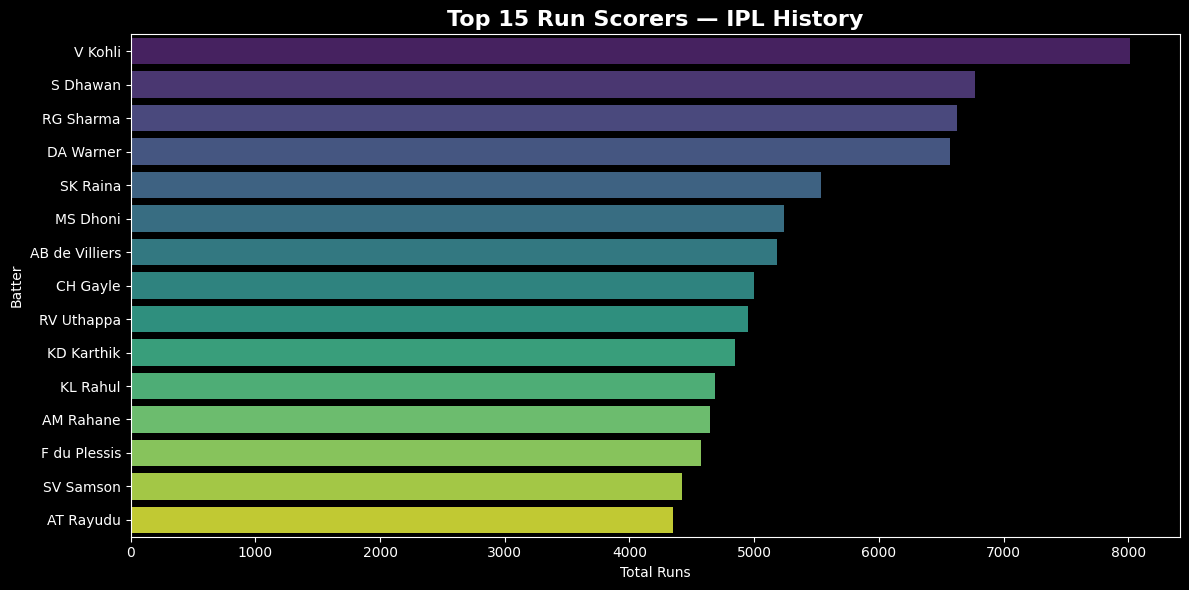

            batter  total_runs
0          V Kohli        8014
1         S Dhawan        6769
2        RG Sharma        6630
3        DA Warner        6567
4         SK Raina        5536
5         MS Dhoni        5243
6   AB de Villiers        5181
7         CH Gayle        4997
8       RV Uthappa        4954
9       KD Karthik        4843
10        KL Rahul        4689
11       AM Rahane        4642
12    F du Plessis        4571
13       SV Samson        4419
14       AT Rayudu        4348


In [2]:
top_scorers = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(15).reset_index()
top_scorers.columns = ['batter', 'total_runs']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_scorers, x='total_runs', y='batter', palette='viridis')
plt.title('Top 15 Run Scorers — IPL History', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Batter')
plt.tight_layout()
plt.savefig('charts/09_top_scorers.png', dpi=150)
plt.show()

print(top_scorers)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16628\4226956774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sixes, x='sixes', y='batter', palette='rocket')


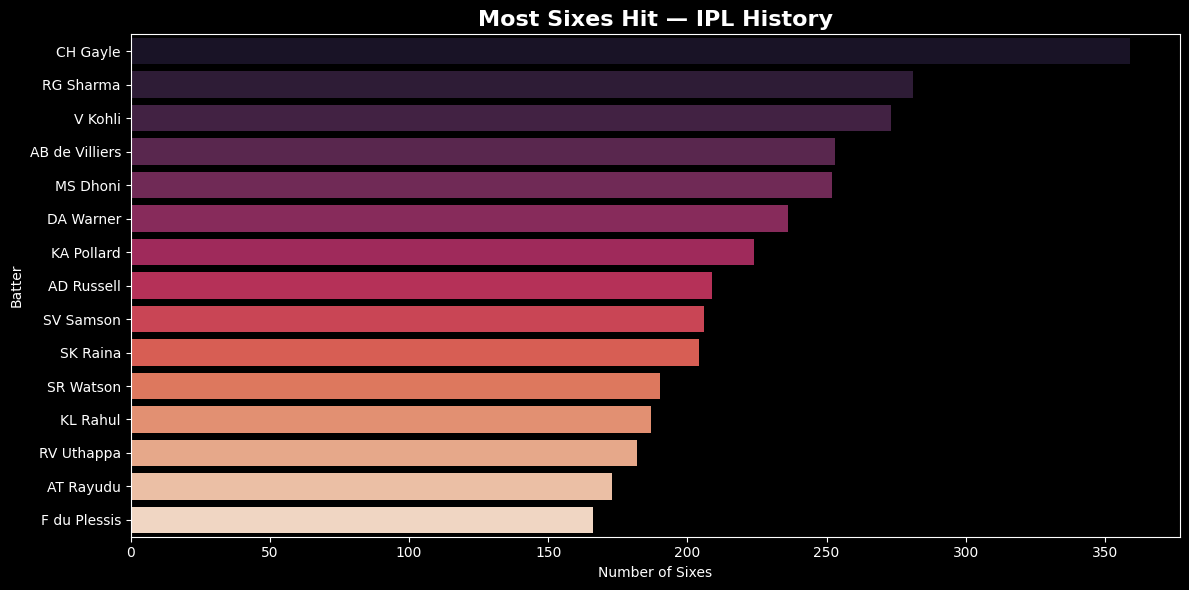

            batter  sixes
0         CH Gayle    359
1        RG Sharma    281
2          V Kohli    273
3   AB de Villiers    253
4         MS Dhoni    252
5        DA Warner    236
6       KA Pollard    224
7       AD Russell    209
8        SV Samson    206
9         SK Raina    204
10       SR Watson    190
11        KL Rahul    187
12      RV Uthappa    182
13       AT Rayudu    173
14    F du Plessis    166


In [3]:
sixes = deliveries[deliveries['batsman_runs'] == 6]
top_sixes = sixes['batter'].value_counts().head(15).reset_index()
top_sixes.columns = ['batter', 'sixes']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_sixes, x='sixes', y='batter', palette='rocket')
plt.title('Most Sixes Hit — IPL History', fontsize=16, fontweight='bold')
plt.xlabel('Number of Sixes')
plt.ylabel('Batter')
plt.tight_layout()
plt.savefig('charts/10_most_sixes.png', dpi=150)
plt.show()

print(top_sixes)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16628\3631620829.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_fours, x='fours', y='batter', palette='mako')


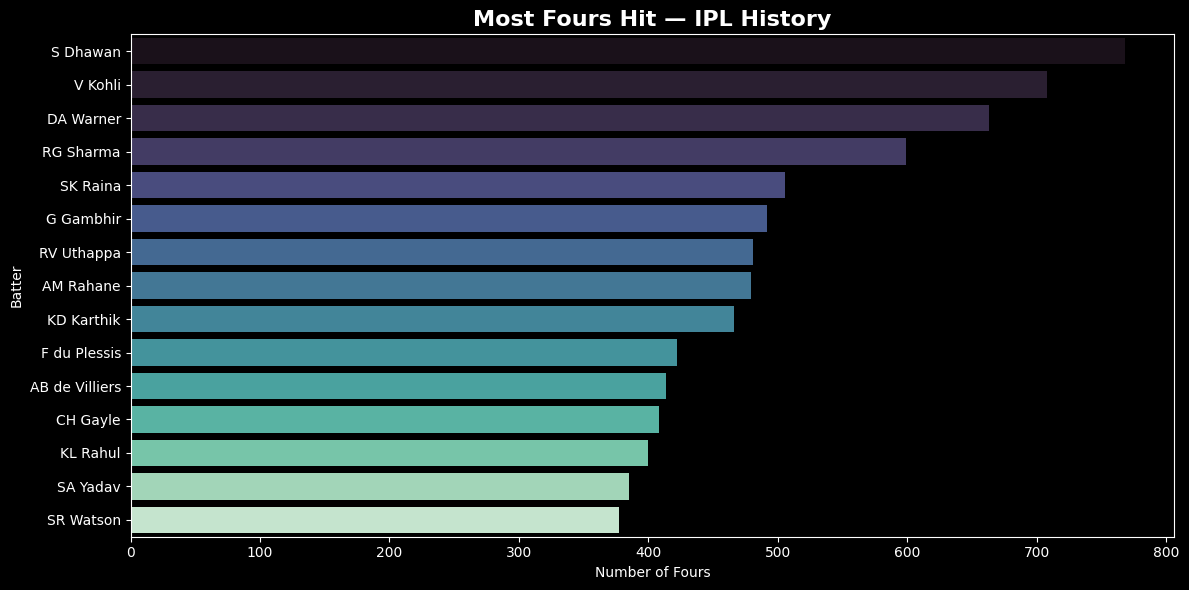

            batter  fours
0         S Dhawan    768
1          V Kohli    708
2        DA Warner    663
3        RG Sharma    599
4         SK Raina    506
5        G Gambhir    492
6       RV Uthappa    481
7        AM Rahane    479
8       KD Karthik    466
9     F du Plessis    422
10  AB de Villiers    414
11        CH Gayle    408
12        KL Rahul    400
13        SA Yadav    385
14       SR Watson    377


In [4]:
fours = deliveries[deliveries['batsman_runs'] == 4]
top_fours = fours['batter'].value_counts().head(15).reset_index()
top_fours.columns = ['batter', 'fours']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_fours, x='fours', y='batter', palette='mako')
plt.title('Most Fours Hit — IPL History', fontsize=16, fontweight='bold')
plt.xlabel('Number of Fours')
plt.ylabel('Batter')
plt.tight_layout()
plt.savefig('charts/11_most_fours.png', dpi=150)
plt.show()

print(top_fours)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16628\3553905759.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sr, x='strike_rate', y='batter', palette='flare')


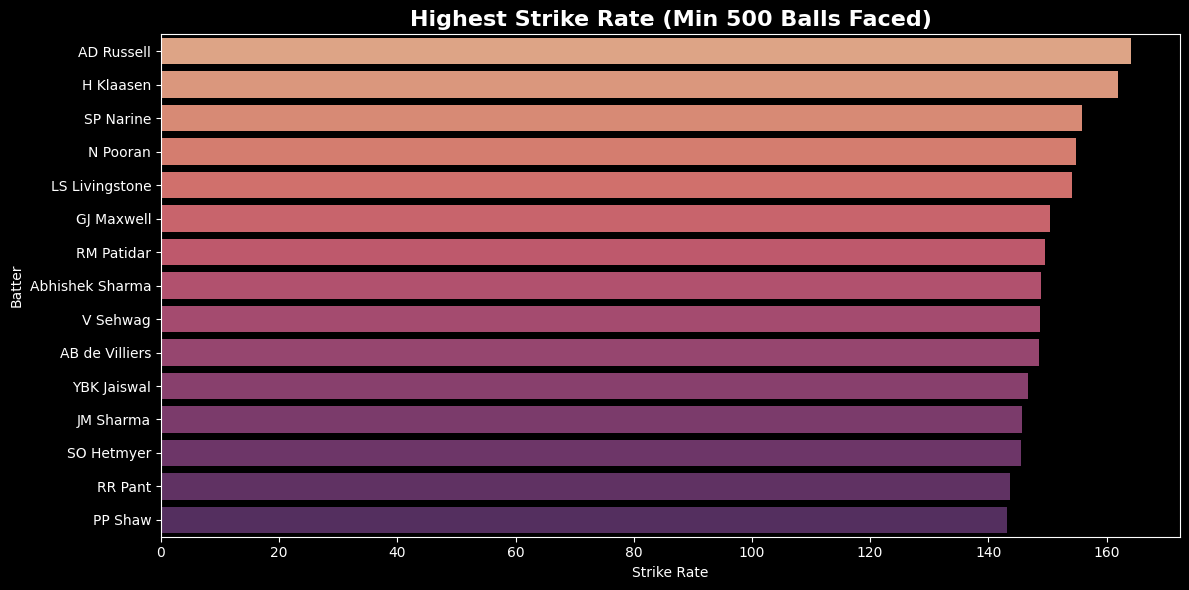

              batter  runs  balls  strike_rate
39        AD Russell  2488   1515   164.224422
208        H Klaasen   993    613   161.990212
561        SP Narine  1534    984   155.894309
396         N Pooran  1769   1143   154.768154
323   LS Livingstone   939    609   154.187192
203       GJ Maxwell  2772   1842   150.488599
485       RM Patidar   799    534   149.625468
70   Abhishek Sharma  1377    925   148.864865
633         V Sehwag  2728   1833   148.827059
30    AB de Villiers  5181   3487   148.580442
662      YBK Jaiswal  1607   1095   146.757991
258        JM Sharma   730    501   145.708583
557       SO Hetmyer  1243    854   145.550351
490          RR Pant  3297   2296   143.597561
441          PP Shaw  1892   1321   143.224830


In [5]:
# Calculate balls faced and runs scored per batter
batter_stats = deliveries.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batsman_runs', 'count')
).reset_index()

# Filter for players with significant balls faced
batter_stats = batter_stats[batter_stats['balls'] >= 500]
batter_stats['strike_rate'] = (batter_stats['runs'] / batter_stats['balls']) * 100

top_sr = batter_stats.sort_values('strike_rate', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_sr, x='strike_rate', y='batter', palette='flare')
plt.title('Highest Strike Rate (Min 500 Balls Faced)', fontsize=16, fontweight='bold')
plt.xlabel('Strike Rate')
plt.ylabel('Batter')
plt.tight_layout()
plt.savefig('charts/12_strike_rate.png', dpi=150)
plt.show()

print(top_sr[['batter', 'runs', 'balls', 'strike_rate']])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16628\2929965113.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bowlers, x='wickets', y='bowler', palette='crest')


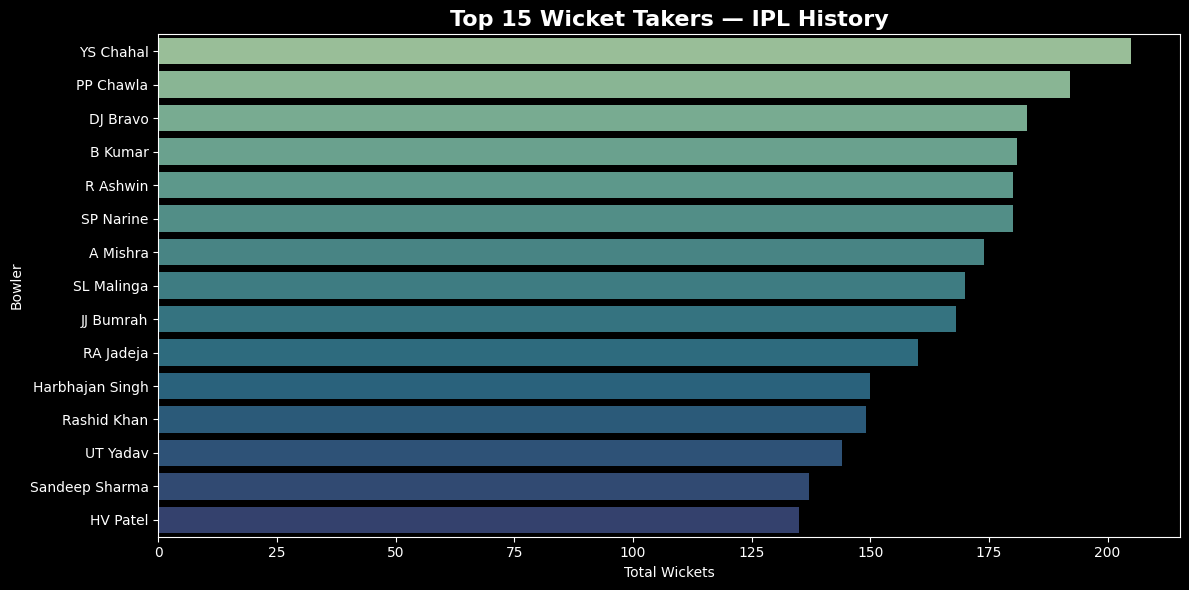

             bowler  wickets
0         YS Chahal      205
1         PP Chawla      192
2          DJ Bravo      183
3           B Kumar      181
4          R Ashwin      180
5         SP Narine      180
6          A Mishra      174
7        SL Malinga      170
8         JJ Bumrah      168
9         RA Jadeja      160
10  Harbhajan Singh      150
11      Rashid Khan      149
12         UT Yadav      144
13   Sandeep Sharma      137
14         HV Patel      135


In [6]:
# Wickets exclude run outs and retired hurt
wicket_deliveries = deliveries[deliveries['is_wicket'] == 1]
valid_dismissals = wicket_deliveries[~wicket_deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'retired out', 'obstructing the field'])]

top_bowlers = valid_dismissals['bowler'].value_counts().head(15).reset_index()
top_bowlers.columns = ['bowler', 'wickets']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_bowlers, x='wickets', y='bowler', palette='crest')
plt.title('Top 15 Wicket Takers — IPL History', fontsize=16, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('charts/13_top_bowlers.png', dpi=150)
plt.show()

print(top_bowlers)

In [ ]:
# Calculate economy rate (runs conceded per over)
bowler_stats = deliveries.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('total_runs', 'count')
).reset_index()

bowler_stats = bowler_stats[bowler_stats['balls_bowled'] >= 600]  # min 100 overs
bowler_stats['overs'] = bowler_stats['balls_bowled'] / 6
bowler_stats['economy'] = bowler_stats['runs_conceded'] / bowler_stats['overs']

best_economy = bowler_stats.sort_values('economy').head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=best_economy, x='economy', y='bowler', palette='ocean')
plt.title('Best Economy Rate (Min 100 Overs Bowled)', fontsize=16, fontweight='bold')
plt.xlabel('Economy Rate (Runs per Over)')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('charts/14_economy_rate.png', dpi=150)
plt.show()

print(best_economy[['bowler', 'runs_conceded', 'overs', 'economy']])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16628\2814660014.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_potm, x='awards', y='player', palette='plasma')


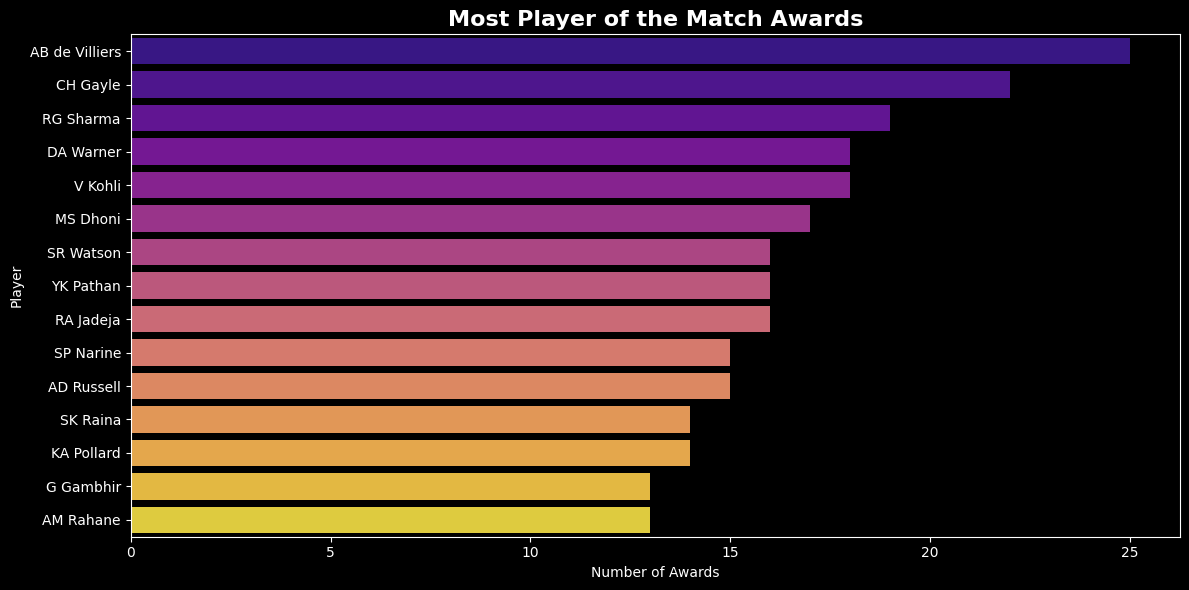

            player  awards
0   AB de Villiers      25
1         CH Gayle      22
2        RG Sharma      19
3        DA Warner      18
4          V Kohli      18
5         MS Dhoni      17
6        SR Watson      16
7        YK Pathan      16
8        RA Jadeja      16
9        SP Narine      15
10      AD Russell      15
11        SK Raina      14
12      KA Pollard      14
13       G Gambhir      13
14       AM Rahane      13


In [7]:
top_potm = matches['player_of_match'].value_counts().head(15).reset_index()
top_potm.columns = ['player', 'awards']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_potm, x='awards', y='player', palette='plasma')
plt.title('Most Player of the Match Awards', fontsize=16, fontweight='bold')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('charts/15_potm_awards.png', dpi=150)
plt.show()

print(top_potm)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16628\3035843097.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=phase_runs, x='phase', y='avg_runs_per_ball', palette='Set2', order=['Powerplay (1-6)', 'Middle (7-16)', 'Death (17-20)'])


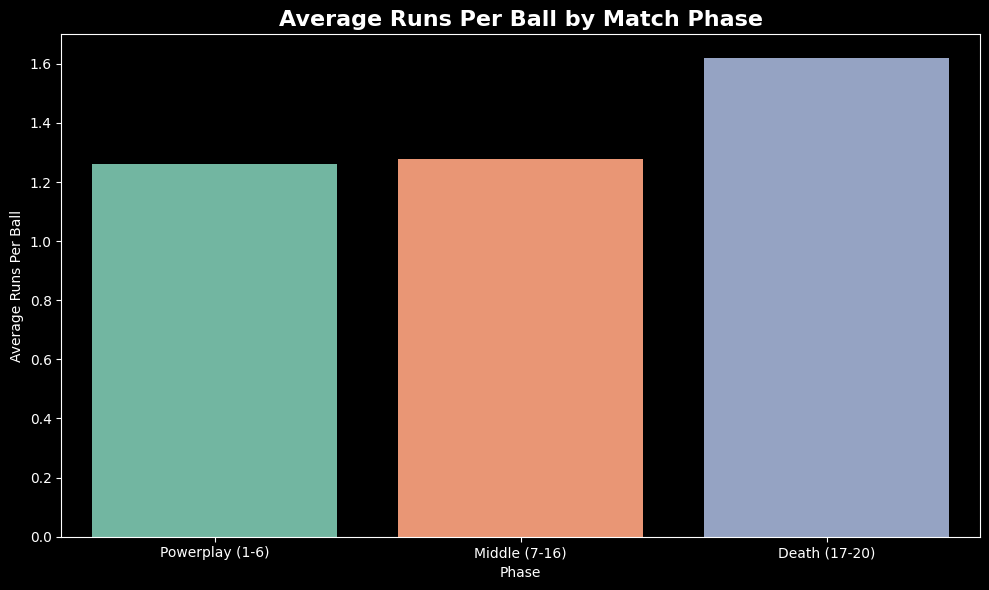

             phase  total_runs  avg_runs_per_ball  total_balls
0    Death (17-20)       75412           1.618839        46584
1    Middle (7-16)      169127           1.277095       132431
2  Powerplay (1-6)      103217           1.260204        81905


In [8]:
# Define phases
def get_phase(over):
    if over < 6:
        return 'Powerplay (1-6)'
    elif over < 16:
        return 'Middle (7-16)'
    else:
        return 'Death (17-20)'

deliveries['phase'] = deliveries['over'].apply(get_phase)

phase_runs = deliveries.groupby('phase')['total_runs'].agg(['sum', 'mean', 'count']).reset_index()
phase_runs.columns = ['phase', 'total_runs', 'avg_runs_per_ball', 'total_balls']

plt.figure(figsize=(10, 6))
sns.barplot(data=phase_runs, x='phase', y='avg_runs_per_ball', palette='Set2', order=['Powerplay (1-6)', 'Middle (7-16)', 'Death (17-20)'])
plt.title('Average Runs Per Ball by Match Phase', fontsize=16, fontweight='bold')
plt.xlabel('Phase')
plt.ylabel('Average Runs Per Ball')
plt.tight_layout()
plt.savefig('charts/16_phase_runs.png', dpi=150)
plt.show()

print(phase_runs)